# Fig. 5m spatial reconstruction marker and LISA panels

Uses `reconstruction/draw/draw_fig.py` functions with outputs redirected to `figures_res/fig5/output/m`.

In [1]:
from pathlib import Path

cwd = Path.cwd()
if (cwd / "figures_res" / "fig5").exists():
    REPO_ROOT = cwd
    FIG5_DIR = cwd / "figures_res" / "fig5"
elif cwd.name == "fig5" and (cwd / "output").exists():
    FIG5_DIR = cwd
    REPO_ROOT = cwd.parents[1]
else:
    raise FileNotFoundError("Run from repo root or figures_res/fig5.")
import sys

DRAW_DIR = REPO_ROOT / "reconstruction" / "draw"
if str(DRAW_DIR) not in sys.path:
    sys.path.insert(0, str(DRAW_DIR))

import draw_fig as df

def redirect_draw_fig_outputs(panel):
    df.FIG_DIR = FIG5_DIR / "output" / panel / "figures"
    df.STAT_DIR = FIG5_DIR / "output" / panel / "stats"
    df.setup()
    print(f"Figures: {df.FIG_DIR}")
    print(f"Stats: {df.STAT_DIR}")


In [2]:
redirect_draw_fig_outputs("m")
marker_stats, expr_store = df.recompute_marker_stats(df.SPATIAL_INPUTS)
marker_stats.to_csv(df.STAT_DIR / "recomputed_marker_stats_spatial.csv", index=False)
recon_tests = df.reconstruction_tests(marker_stats, expr_store)
recon_tests.to_csv(df.STAT_DIR / "recomputed_reconstruction_ttests_spatial.csv", index=False)

df.plot_spatial_marker_significance(marker_stats)
lisa = df.read_lisa_table()
lisa.to_csv(df.STAT_DIR / "lisa_plot_input.csv", index=False)
df.plot_lisa(lisa)
if df.DRAW_RECON_COMPARATOR_HEATMAPS:
    df.plot_reconstruction_test_heatmap(recon_tests)


Figures: /home/zzj/lare/figures_res/fig5/output/m/figures
Stats: /home/zzj/lare/figures_res/fig5/output/m/stats
Processing SpaGCN / SpaGCN baseline: /home/zzj/lare/reconstruction/home_old/spaGCN_orig/reclustered_adata_test_woLasso_42_rsc.h5ad
Processing SpaGCN / Recon-LassoARE: /home/zzj/lare/reconstruction/home_old/spaGCN/reclustered_adata_test_woLasso_42_rsc.h5ad


## Display saved PNG outputs

Run this cell after the plotting cells above to render the saved PNG files directly inside the notebook for review.

In [3]:
from pathlib import Path
from IPython.display import Image, Markdown, display


def display_saved_pngs(output_dir, width=1000):
    output_dir = Path(output_dir)
    pngs = sorted(output_dir.glob("*.png"))
    if not pngs:
        print(f"No PNG files found in {output_dir}. Run the plotting cells above first.")
        return
    for png in pngs:
        display(Markdown(f"### {png.name}"))
        display(Image(filename=str(png), width=width))


### lisa_target_proportion.png

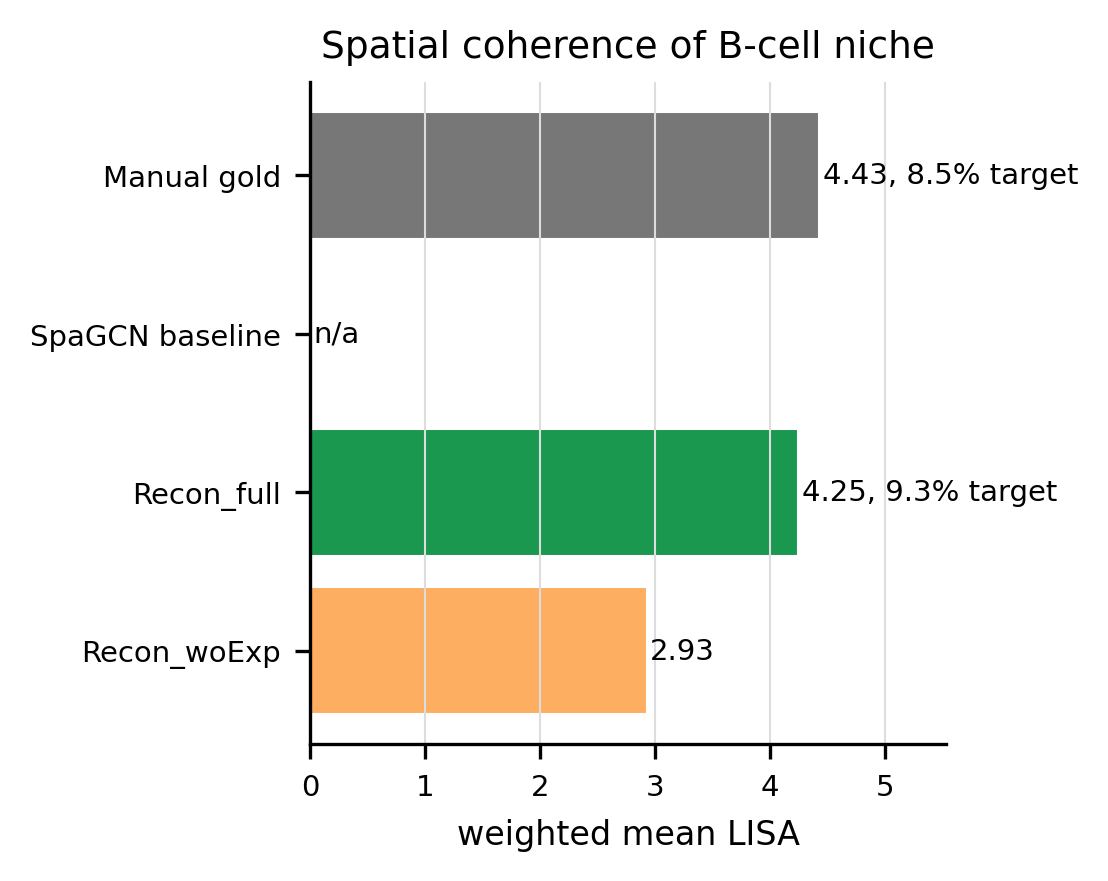

### spagcn_b_t_marker_significance_recomputed_ttest.png

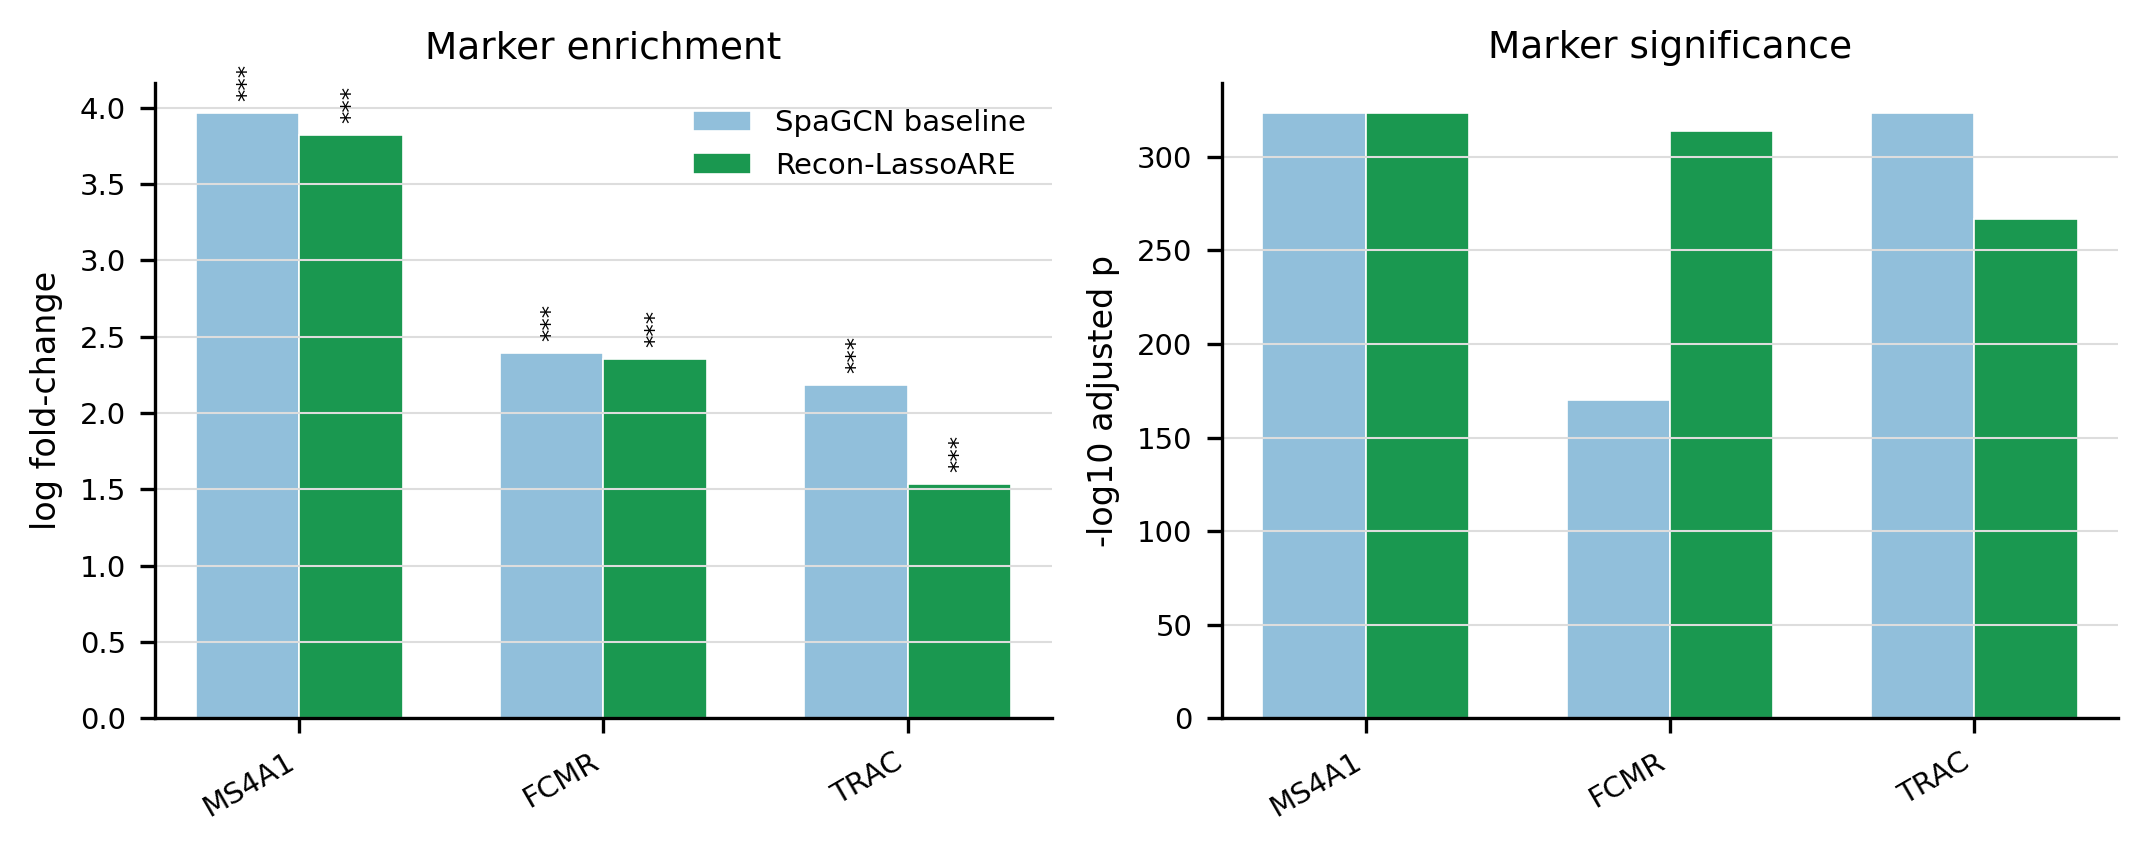

In [4]:
display_saved_pngs(df.FIG_DIR, width=1000)
